# <span style="color:yellow;">Understanding Base64 Encoding</span>

- This script demonstrates Base64 encoding and decoding using Python's built-in `base64` module. 
- We'll work with text/images to see how binary data is converted to text and back, with visualizations at each step.

# Step 1: Import Required Libraries
- We'll use standard libraries for `Base64` operations and image processing, 
- plus matplotlib for visualization.

In [1]:
# Import built-in modules
import base64
import io

# Import image processing and visualization libraries
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image  # For image handling

# For inline image display in Jupyter environments
%matplotlib inline

print("Step 1: Libraries imported successfully")

Step 1: Libraries imported successfully


---

# Step 2: Load the Local Image

In [4]:
image_path = "Pedestrians.jpg"

In [5]:
# Open the image file in binary mode to get raw binary data
with open(image_path, "rb") as image_file:
    image_bytes = image_file.read()  # Raw binary data of the image

In [6]:
# Verify image loading
print(f"Step 2: \nImage loaded from {image_path}.\nSize: {len(image_bytes)} bytes")

Step 2: 
Image loaded from Pedestrians.jpg.
Size: 401880 bytes


# Step 3: Display the Original Image
Let's visualize the image before any encoding to see the original content.

In [7]:
# Convert binary data to a PIL Image object
original_img = Image.open(io.BytesIO(image_bytes))

In [8]:
# Convert to numpy array for consistent plotting
img_array = np.array(original_img)

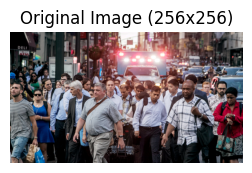

In [9]:
# Display the image
plt.ioff()
plt.figure(figsize=(3, 3))
plt.imshow(img_array)
plt.title("Original Image (256x256)")
plt.axis("off")
plt.show()

In [10]:
print("Step 3: Original image displayed")

Step 3: Original image displayed


# Step 4: Encode text to Base64 characters
- Let's use a simple 3-byte text string for demonstration
- Choose a 3-byte text string (each character is 1 byte in `ASCII`)

## Step 4.1: Original text (3 bytes)

In [11]:
text = "Cat"
print(f"Original text: '{text}' (3 characters = 3 bytes)")

Original text: 'Cat' (3 characters = 3 bytes)


## Step 4.2: Convert to ASCII byte values

In [12]:
text_bytes = text.encode('utf-8')
print(f"Byte values (decimal): \n{[b for b in text_bytes]}")

Byte values (decimal): 
[67, 97, 116]


## Step 4.3: Show 8-bit binary for each byte

In [13]:
byte1 = text_bytes[0]  # 'C'
byte2 = text_bytes[1]  # 'a'
byte3 = text_bytes[2]  # 't'

In [14]:
bin1 = bin(byte1)[2:].zfill(8)  # 8-bit binary string
bin2 = bin(byte2)[2:].zfill(8)
bin3 = bin(byte3)[2:].zfill(8)

In [15]:
print(f"8-bit binary breakdown:")
print(f"'C' (67) → {bin1}")
print(f"'a' (97) → {bin2}")
print(f"'t' (116) → {bin3}")

8-bit binary breakdown:
'C' (67) → 01000011
'a' (97) → 01100001
't' (116) → 01110100


## Step 4.4: Combine into 24-bit stream

In [16]:
# Define ANSI color codes
RED = "\033[31m"
GREEN = "\033[32m"
BLUE = "\033[34m"
RESET = "\033[0m"

# Split into 8-bit segments with colors
combined = bin1 + bin2 + bin3  # Define the full 24-bit string

colored_combined = (
    f"{RED}{bin1}{RESET}"  # First 8 bits in red
    f"{GREEN}{bin2}{RESET}"  # Middle 8 bits in green
    f"{BLUE}{bin3}{RESET}"  # Last 8 bits in blue
)

print(f"\nCombined 24-bit stream (color-coded by original byte):")
print(colored_combined)
print(f"Length check: {len(combined)} bits (3 bytes × 8 bits)")


Combined 24-bit stream (color-coded by original byte):
010000110110000101110100
Length check: 24 bits (3 bytes × 8 bits)


## Step 4.5: Split into 4 × 6-bit groups

In [17]:
# Split 24-bit stream into 4×6-bit groups
group1 = combined[0:6]
group2 = combined[6:12]
group3 = combined[12:18]
group4 = combined[18:24]

# Define ANSI color codes for four distinct colors
COLOR1 = "\033[31m"   # Red
COLOR2 = "\033[32m"   # Green
COLOR3 = "\033[34m"   # Blue
COLOR4 = "\033[35m"   # Magenta
RESET = "\033[0m"     # Reset to default

# Convert 6-bit groups to decimal (from previous steps)
dec1 = int(group1, 2)
dec2 = int(group2, 2)
dec3 = int(group3, 2)
dec4 = int(group4, 2)

# Create color-coded 6-bit groups with their decimal values
colored_groups = (
    f"{COLOR1}{group1} ({dec1}){RESET} + "
    f"{COLOR2}{group2} ({dec2}){RESET} + "
    f"{COLOR3}{group3} ({dec3}){RESET} + "
    f"{COLOR4}{group4} ({dec4}){RESET}"
)

print(f"\n6-bit groups (with decimal values) in different colors:")
print(colored_groups)
print(f"\nCombined 24-bit stream (same color coding):")
print(f"{COLOR1}{group1}{RESET}{COLOR2}{group2}{RESET}{COLOR3}{group3}{RESET}{COLOR4}{group4}{RESET}")
print(f"\nDecimal values of 6-bit groups: "
      f"{COLOR1}{dec1}{RESET}, {COLOR2}{dec2}{RESET}, {COLOR3}{dec3}{RESET}, {COLOR4}{dec4}{RESET}")


6-bit groups (with decimal values) in different colors:
010000 (16) + 110110 (54) + 000101 (5) + 110100 (52)

Combined 24-bit stream (same color coding):
010000110110000101110100

Decimal values of 6-bit groups: 16, 54, 5, 52


## Step 4.6: Print both 24-bit strings for comparison

In [18]:
print("\n24-bit string comparison:")
print(f"From Step 4.4 (original byte grouping): \n{colored_combined}")
print(f"From Step 4.5 (6-bit group grouping):  \n{COLOR1}{group1}{RESET}{COLOR2}{group2}{RESET}{COLOR3}{group3}{RESET}{COLOR4}{group4}{RESET}")
print(f"Are they identical? {combined == group1 + group2 + group3 + group4}")


24-bit string comparison:
From Step 4.4 (original byte grouping): 
010000110110000101110100
From Step 4.5 (6-bit group grouping):  
010000110110000101110100
Are they identical? True


## <span style='color:red;'>Base64 Character Table</span>

<table border="0" cellpadding="8" cellspacing="0" style="border-collapse: separate; border-spacing: 0; width: 100%; max-width: 1000px; border-radius: 8px; overflow: hidden; box-shadow: 0 4px 12px rgba(0,0,0,0.1);">
  <thead>
    <tr style="background: linear-gradient(135deg, #4a6cf7 0%, #1a36b9 100%); color: white;">
      <th style="padding: 12px; text-align: center; border-bottom: 2px solid #ffffff20;">6-bit Value</th>
      <th style="padding: 12px; text-align: center; border-bottom: 2px solid #ffffff20;">Decimal Index</th>
      <th style="padding: 12px; text-align: center; border-bottom: 2px solid #ffffff20;">Character</th>
      <th style="padding: 12px; text-align: center; border-bottom: 2px solid #ffffff20;">6-bit Value</th>
      <th style="padding: 12px; text-align: center; border-bottom: 2px solid #ffffff20;">Decimal Index</th>
      <th style="padding: 12px; text-align: center; border-bottom: 2px solid #ffffff20;">Character</th>
      <th style="padding: 12px; text-align: center; border-bottom: 2px solid #ffffff20;">6-bit Value</th>
      <th style="padding: 12px; text-align: center; border-bottom: 2px solid #ffffff20;">Decimal Index</th>
      <th style="padding: 12px; text-align: center; border-bottom: 2px solid #ffffff20;">Character</th>
      <th style="padding: 12px; text-align: center; border-bottom: 2px solid #ffffff20;">6-bit Value</th>
      <th style="padding: 12px; text-align: center; border-bottom: 2px solid #ffffff20;">Decimal Index</th>
      <th style="padding: 12px; text-align: center; border-bottom: 2px solid #ffffff20;">Character</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color: #f0f7ff;">
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-family: monospace;">000000</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff;">0</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-weight: bold;">A</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-family: monospace;">010000</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff;">16</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-weight: bold;">Q</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-family: monospace;">100000</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff;">32</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-weight: bold;">g</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-family: monospace;">110000</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff;">48</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-weight: bold;">w</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-family: monospace;">000001</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0;">1</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-weight: bold;">B</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-family: monospace;">010001</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0;">17</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-weight: bold;">R</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-family: monospace;">100001</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0;">33</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-weight: bold;">h</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-family: monospace;">110001</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0;">49</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-weight: bold;">x</td>
    </tr>
    <tr style="background-color: #f0f7ff;">
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-family: monospace;">000010</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff;">2</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-weight: bold;">C</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-family: monospace;">010010</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff;">18</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-weight: bold;">S</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-family: monospace;">100010</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff;">34</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-weight: bold;">i</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-family: monospace;">110010</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff;">50</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-weight: bold;">y</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-family: monospace;">000011</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0;">3</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-weight: bold;">D</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-family: monospace;">010011</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0;">19</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-weight: bold;">T</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-family: monospace;">100011</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0;">35</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-weight: bold;">j</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-family: monospace;">110011</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0;">51</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-weight: bold;">z</td>
    </tr>
    <tr style="background-color: #f0f7ff;">
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-family: monospace;">000100</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff;">4</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-weight: bold;">E</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-family: monospace;">010100</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff;">20</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-weight: bold;">U</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-family: monospace;">100100</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff;">36</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-weight: bold;">k</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-family: monospace;">110100</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff;">52</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-weight: bold;">0</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-family: monospace;">000101</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0;">5</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-weight: bold;">F</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-family: monospace;">010101</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0;">21</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-weight: bold;">V</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-family: monospace;">100101</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0;">37</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-weight: bold;">l</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-family: monospace;">110101</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0;">53</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-weight: bold;">1</td>
    </tr>
    <tr style="background-color: #f0f7ff;">
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-family: monospace;">000110</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff;">6</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-weight: bold;">G</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-family: monospace;">010110</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff;">22</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-weight: bold;">W</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-family: monospace;">100110</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff;">38</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-weight: bold;">m</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-family: monospace;">110110</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff;">54</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-weight: bold;">2</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-family: monospace;">000111</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0;">7</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-weight: bold;">H</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-family: monospace;">010111</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0;">23</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-weight: bold;">X</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-family: monospace;">100111</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0;">39</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-weight: bold;">n</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-family: monospace;">110111</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0;">55</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-weight: bold;">3</td>
    </tr>
    <tr style="background-color: #f0f7ff;">
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-family: monospace;">001000</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff;">8</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-weight: bold;">I</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-family: monospace;">011000</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff;">24</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-weight: bold;">Y</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-family: monospace;">101000</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff;">40</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-weight: bold;">o</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-family: monospace;">111000</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff;">56</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-weight: bold;">4</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-family: monospace;">001001</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0;">9</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-weight: bold;">J</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-family: monospace;">011001</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0;">25</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-weight: bold;">Z</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-family: monospace;">101001</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0;">41</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-weight: bold;">p</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-family: monospace;">111001</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0;">57</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-weight: bold;">5</td>
    </tr>
    <tr style="background-color: #f0f7ff;">
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-family: monospace;">001010</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff;">10</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-weight: bold;">K</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-family: monospace;">011010</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff;">26</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-weight: bold;">a</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-family: monospace;">101010</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff;">42</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-weight: bold;">q</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-family: monospace;">111010</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff;">58</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-weight: bold;">6</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-family: monospace;">001011</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0;">11</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-weight: bold;">L</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-family: monospace;">011011</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0;">27</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-weight: bold;">b</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-family: monospace;">101011</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0;">43</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-weight: bold;">r</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-family: monospace;">111011</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0;">59</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-weight: bold;">7</td>
    </tr>
    <tr style="background-color: #f0f7ff;">
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-family: monospace;">001100</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff;">12</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-weight: bold;">M</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-family: monospace;">011100</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff;">28</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-weight: bold;">c</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-family: monospace;">101100</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff;">44</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-weight: bold;">s</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-family: monospace;">111100</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff;">60</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-weight: bold;">8</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-family: monospace;">001101</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0;">13</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-weight: bold;">N</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-family: monospace;">011101</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0;">29</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-weight: bold;">d</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-family: monospace;">101101</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0;">45</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-weight: bold;">t</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-family: monospace;">111101</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0;">61</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-weight: bold;">9</td>
    </tr>
    <tr style="background-color: #f0f7ff;">
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-family: monospace;">001110</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff;">14</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-weight: bold;">O</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-family: monospace;">011110</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff;">30</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-weight: bold;">e</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-family: monospace;">101110</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff;">46</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-weight: bold;">u</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-family: monospace;">111110</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff;">62</td>
      <td style="text-align: center; border-bottom: 1px solid #e0e7ff; font-weight: bold;">+</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-family: monospace;">001111</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0;">15</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-weight: bold;">P</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-family: monospace;">011111</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0;">31</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-weight: bold;">f</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-family: monospace;">101111</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0;">47</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-weight: bold;">v</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-family: monospace;">111111</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0;">63</td>
      <td style="text-align: center; border-bottom: 1px solid #f0f0f0; font-weight: bold;">/</td>
    </tr>
  </tbody>
</table>
    

## Step 4.7: Map to Base64 characters

In [19]:
base64_table = "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789+/"
char1 = base64_table[dec1]
char2 = base64_table[dec2]
char3 = base64_table[dec3]
char4 = base64_table[dec4]

print(f"\nBase64 characters: '{char1}{char2}{char3}{char4}'")


Base64 characters: 'Q2F0'


## Step 4.8: Verify with built-in function

In [20]:
encoded = base64.b64encode(text_bytes).decode('utf-8')
print(f"\nBuilt-in encoder result: '{encoded}' (They match!)")


Built-in encoder result: 'Q2F0' (They match!)


# Step 5: Encode Image to Base64
Encode the Rocky Canyon Image to Base6

## Step 5.1: Confirm image source and properties

Step 5.1: Using Rocky Canyon image from Step 3
Original image binary size: 401,880 bytes
First 5 bytes of raw image data (decimal): [255, 216, 255, 224, 0]
Last 5 bytes of raw image data (decimal): [214, 166, 76, 255, 217]


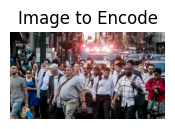

In [21]:
# Using the same image data loaded in Step 2 and displayed in Step 3
print(f"Step 5.1: Using Rocky Canyon image from Step 3")
print(f"Original image binary size: {len(image_bytes):,} bytes")
print(f"First 5 bytes of raw image data (decimal): {[b for b in image_bytes[:5]]}")
print(f"Last 5 bytes of raw image data (decimal): {[b for b in image_bytes[-5:]]}")

# Quick visual reminder of the image we're working with
plt.figure(figsize=(2, 2))
plt.imshow(img_array)
plt.title("Image to Encode")
plt.axis("off")
plt.show()


## Step 5.2: Perform Base64 encoding on the entire image

In [22]:
print("Step 5.2: Starting Base64 encoding of the image...")
base64_encoded = base64.b64encode(image_bytes).decode('utf-8')
print(f"Encoding complete! Generated {len(base64_encoded):,} characters")

Step 5.2: Starting Base64 encoding of the image...
Encoding complete! Generated 535,840 characters


## Step 5.3: Compare original and encoded sizes

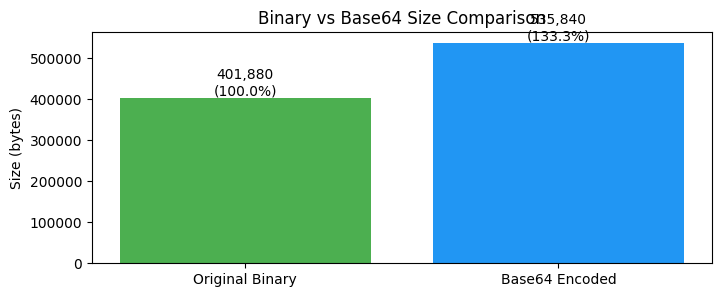

Size increase: 33.3% (theoretical ideal is 33.3%)


In [23]:
# %%
original_size = len(image_bytes)
encoded_size = len(base64_encoded)
size_increase = (encoded_size / original_size - 1) * 100

# Visual size comparison
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 3))
bars = plt.bar(["Original Binary", "Base64 Encoded"], [original_size, encoded_size], 
        color=['#4CAF50', '#2196F3'])

# Add labels and annotations
plt.ylabel("Size (bytes)")
plt.title("Binary vs Base64 Size Comparison")
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:,}\n({height/original_size:.1%})',
            ha='center', va='bottom')

plt.show()

print(f"Size increase: {round(size_increase, 1)}% (theoretical ideal is 33.3%)")


## Step 5.4: Show preview of encoded string

In [24]:
# %%
print(f"\nStep 5.4: Encoded string preview")
print(f"First 100 characters:\n{base64_encoded[:100]}...")
print(f"\nLast 100 characters:\n...{base64_encoded[-100:]}")

# Show character distribution in the encoded string
print(f"\nTotal characters in encoded string: {len(base64_encoded):,}")
print(f"Unique characters used: {len(set(base64_encoded))} (out of 64 possible)")



Step 5.4: Encoded string preview
First 100 characters:
/9j/4AAQSkZJRgABAQEAyADIAAD/2wBDAAUDBAQEAwUEBAQFBQUGBwwIBwcHBw8LCwkMEQ8SEhEPERETFhwXExQaFRERGCEYGh0d...

Last 100 characters:
...xxXbiVxPN8qTi7QbmagM2YTJtFrWokjcGlA/yVW1UcvNskqdIWOTbHJpjuNOBAVht0hOSPY5qeTRfFNFVymktuvJTnBPPNamTP/Z

Total characters in encoded string: 535,840
Unique characters used: 64 (out of 64 possible)


## Step 5.5: Verify encoding with a 6-byte segment
 (should produce 8 Base64 chars)

In [25]:
# Select a 6-byte segment from the middle of the image
segment_start = len(image_bytes) // 2
test_segment = image_bytes[segment_start:segment_start+6]

# Show the raw bytes
print(f"Selected 6-byte segment (decimal values): {list(test_segment)}")
print(f"Same segment in hex: {[hex(b) for b in test_segment]}")

# Encode and decode the 6-byte segment
segment_encoded = base64.b64encode(test_segment).decode('utf-8')
segment_decoded = base64.b64decode(segment_encoded)

print(f"\nEncoded segment (8 characters): '{segment_encoded}'")
print(f"Decoded segment matches original: {segment_decoded == test_segment}")

Selected 6-byte segment (decimal values): [164, 139, 111, 209, 70, 182]
Same segment in hex: ['0xa4', '0x8b', '0x6f', '0xd1', '0x46', '0xb6']

Encoded segment (8 characters): 'pItv0Ua2'
Decoded segment matches original: True


## Step 5.6: Decode Base64 Back to Binary
Convert the Base64 string back into the original binary data.

In [26]:
# %%
print("Step 5.6: Decoding Base64 string back to binary...")
base64_decoded = base64.b64decode(base64_encoded)

# Verify the decoded data matches the original
is_match = (base64_decoded == image_bytes)
print(f"Decoding complete! Decoded size: {len(base64_decoded):,} bytes")
print(f"Does decoded data match original? {is_match}")


Step 5.6: Decoding Base64 string back to binary...
Decoding complete! Decoded size: 401,880 bytes
Does decoded data match original? True


## Step 5.7: Display the Decoded Image
Visualize the image reconstructed from the decoded binary data to confirm integrity.

Successfully converted decoded data back to image format


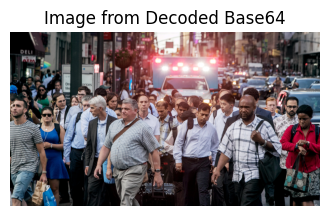

In [27]:
decoded_img = Image.open(io.BytesIO(base64_decoded))
decoded_array = np.array(decoded_img)
print("Successfully converted decoded data back to image format")

# Display the decoded image
plt.figure(figsize=(4, 4))
plt.imshow(decoded_array)
plt.title("Image from Decoded Base64")
plt.axis("off")
plt.show()

## Step 5.8: Compare Original and Decoded Images
We'll use a difference image to mathematically confirm the images are identical.

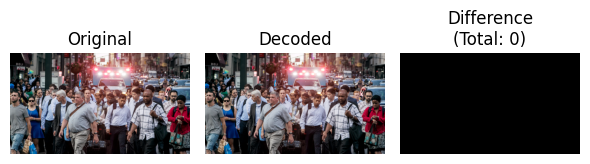

Image comparison results:
- Total pixel difference: 0
- Maximum single pixel difference: 0
A total difference of 0 confirms perfect reconstruction!


In [28]:
# Calculate pixel-wise difference (should be all zeros)
difference = np.abs(img_array - decoded_array)
total_diff = np.sum(difference)
max_diff = np.max(difference) if difference.size > 0 else 0

# Display the difference image
plt.figure(figsize=(6, 3))

# Original image
plt.subplot(1, 3, 1)
plt.imshow(img_array)
plt.title("Original")
plt.axis("off")

# Decoded image
plt.subplot(1, 3, 2)
plt.imshow(decoded_array)
plt.title("Decoded")
plt.axis("off")

# Difference image
plt.subplot(1, 3, 3)
plt.imshow(difference, cmap='gray')
plt.title(f"Difference\n(Total: {total_diff})")
plt.axis("off")

plt.tight_layout()
plt.show()

print(f"Image comparison results:")
print(f"- Total pixel difference: {total_diff}")
print(f"- Maximum single pixel difference: {max_diff}")
print("A total difference of 0 confirms perfect reconstruction!")

# Step 6: Practical Use Case - Embed Image in HTML

Normally, web pages display images by `linking` to separate image files (e.g., src="*image.jpg*"). This requires:

- A separate image file stored on the server
- An additional HTTP request to fetch that file when the page loads

`Base64` solves this by converting the image's binary data into a text string that can be directly embedded into the HTML code. 

This creates a `self-contained` file with no external dependencies.

## Step 6.1: Create HTML code with embedded Base64 image

In [29]:
html_code = f"""
<html>
  <body>
    <h3>Image Embedded via Base64</h3>
    <img src="data:image/jpeg;base64,{base64_encoded}" width="256">
  </body>
</html>
"""

The `html_code` variable constructs a simple HTML document where the image source (`src`) isn't a file path, but a special data: URL containing the Base64-encoded image data:

```html
<img src="data:image/jpeg;base64,{base64_encoded}" width="256">```

- data:image/jpeg tells the browser: "This is binary data for a JPEG image"
- base64, indicates the data is Base64-encoded
- {base64_encoded} is the actual encoded string from your image

## Step 6.2: Display the HTML in Jupyter


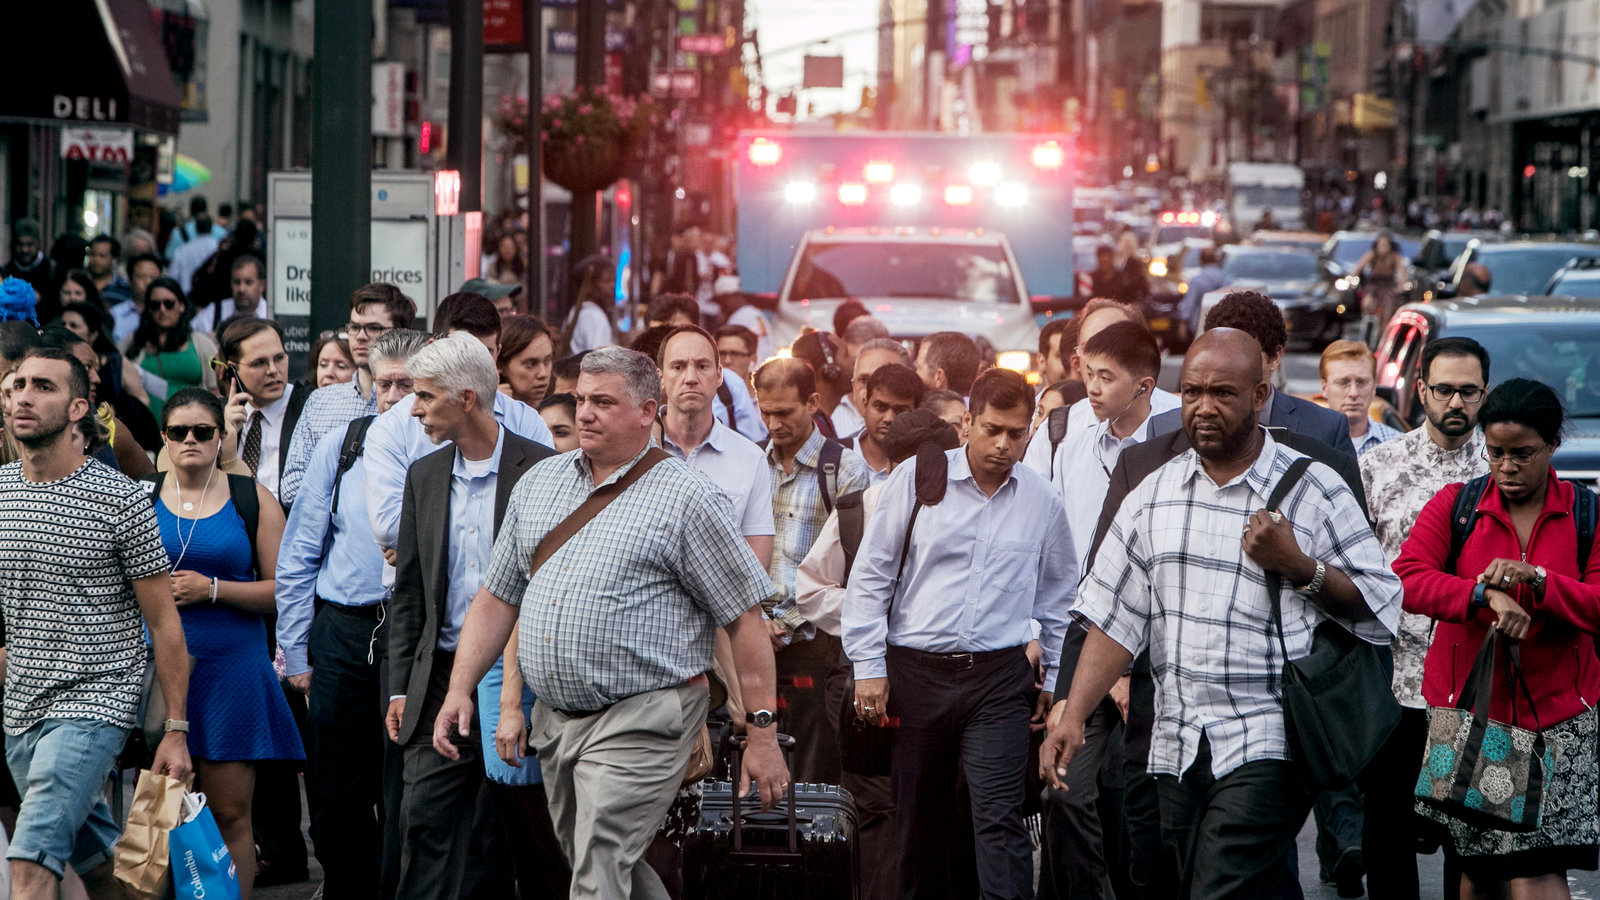

In [30]:
from IPython.display import HTML
display(HTML(html_code))

In [31]:
print("Step 6: \nHTML with embedded Base64 image displayed")

Step 6: 
HTML with embedded Base64 image displayed


# Summary

- `Base64` converts binary data to ASCII text for safe transmission in text-based systems
- Encoding/decoding is `lossless` when done correctly
- Common uses include embedding media in HTML, email attachments, and API data transfer
- The tradeoff: Base64 increases data size by **~33%** compared to original binary